In [72]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoModelForCausalLM,GPT2Tokenizer
import requests

from typing import List, Tuple

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [82]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Explicitly set the loss type
gpt2.config.loss_type = "ForCausalLMLoss"

In [83]:
# Function to get top-n frequently occurring tokens from the model
def topNTokens(tokens: torch.Tensor, n: int)->Tuple[torch.Tensor, torch.Tensor]:
  uniq, counts = torch.unique(tokens, return_counts=True)
  freq = torch.argsort(counts, descending=True)
  return uniq[freq[:n]], counts[freq[:n]]

In [84]:
tokens = tokenizer.encode("Hello, my dog is cute", return_tensors="pt")
top100, counts = topNTokens(tokens,100)
print(top100)
print(counts)

tensor([   11,   318,   616,  3290, 13779, 15496])
tensor([1, 1, 1, 1, 1, 1])


In [95]:
# Function to generate random tokens from a model
def countFreqTokens(model: AutoModelForCausalLM,
                    topN: torch.Tensor,
                    numreps: int = 10,
                    numtoks:int = 100
                    )->torch.Tensor:
  #
  # random starting tokens
  randstarts = torch.randint(tokenizer.vocab_size,(numreps,1)).to(device)

  # generate some data
  out = model.generate(
    randstarts,
    max_length = numtoks + 1,
    min_length = numtoks + 1,
    do_sample   = True,
    bad_words_ids = [tokenizer.encode(tokenizer.eos_token)],
    pad_token_id = tokenizer.encode(tokenizer.eos_token)[0]
  )

  eval = np.mean(100*np.isin(out[:,1:].cpu().numpy(), topN[0].numpy()).flatten())

  return eval

In [108]:
# Function to train the model
def trainTheModel(lr: int,
                  num_epochs:int,
                  tokens: torch.Tensor,
                  batch_size:int,
                  seq_len:int,
                  topN:torch.Tensor,
                  print_toggle: bool = False)->Tuple[np.array,float, float]:

    # download the model
    model = AutoModelForCausalLM.from_pretrained("gpt2")
    model.to(device)

    # pre-train evaluation
    preTrainEval = countFreqTokens(model,topN,10,100)

    # optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # initialize losses
    train_loss = np.zeros(num_epochs)

    # train the model
    for epochi in range(num_epochs):

        # create a batch with random data
        ix = torch.randint(len(tokens)-seq_len, size=(batch_size,1))
        X = tokens[ix[:,None] + torch.arange(seq_len)].to(device)

        # initialize the gradients
        model.zero_grad(set_to_none=True)

        # forward pass
        output = model(X, labels=X)

        # calculate loss
        loss = output.loss
        train_loss[epochi] = loss.item()

        # backpropagate
        loss.backward()

        # update parameters
        optimizer.step()

        if print_toggle and (epochi+1) % 100 == 0:
            print(f"Epoch {epochi+1:5}, Loss: {loss.item():.3f}")

    # post-train evaluation
    postTrainEval = countFreqTokens(model,topN,10,100)

    return train_loss, preTrainEval, postTrainEval

In [92]:
# tokenize the text
# Gulliver's travels :)
text = requests.get('https://www.gutenberg.org/cache/epub/829/pg829.txt').text

In [97]:
lr = 1e-5
num_epochs = 1000
tokens = tokenizer.encode(text, return_tensors='pt')[0]
batch_size = 16
seq_len = 256
top100 = topNTokens(tokens,100)

train_loss, preTrainEval, postTrainEval = trainTheModel(lr, num_epochs, tokens, batch_size, seq_len, top100, True)


Epoch     1, Loss: 5.440
Epoch   101, Loss: 3.464
Epoch   201, Loss: 3.191
Epoch   301, Loss: 3.051
Epoch   401, Loss: 2.871
Epoch   501, Loss: 2.785
Epoch   601, Loss: 2.700
Epoch   701, Loss: 2.474
Epoch   801, Loss: 2.344
Epoch   901, Loss: 2.473


In [107]:
lr = [1e-4, 1e-5, 1e-6]
num_epochs = 800
tokens = tokenizer.encode(text, return_tensors='pt')[0]
batch_size = 16
seq_len = 256
top100 = topNTokens(tokens,100)

lr_evals = []

for i, lri in enumerate(lr):
  print(f"Training with learning rate {lri}")
  print("--"*20)
  train_loss, preTrainEval, postTrainEval = trainTheModel(lri, num_epochs, tokens, batch_size, seq_len, top100, True)
  lr_evals.append({
      'learning_rate': lri,
      'train_loss': train_loss,
      'pre_train_eval': preTrainEval,
      'post_train_eval': postTrainEval
  })


Training with learning rate 0.0001
----------------------------------------
Epoch     1, Loss: 5.282
Epoch   101, Loss: 2.605
Epoch   201, Loss: 2.167
Epoch   301, Loss: 1.206
Epoch   401, Loss: 0.807
Epoch   501, Loss: 0.506
Epoch   601, Loss: 0.348
Epoch   701, Loss: 0.224
Training with learning rate 1e-05
----------------------------------------
Epoch     1, Loss: 5.380
Epoch   101, Loss: 3.487
Epoch   201, Loss: 3.180
Epoch   301, Loss: 2.999
Epoch   401, Loss: 2.858
Epoch   501, Loss: 2.848
Epoch   601, Loss: 2.665
Epoch   701, Loss: 2.712
Training with learning rate 1e-06
----------------------------------------
Epoch     1, Loss: 5.357
Epoch   101, Loss: 4.427
Epoch   201, Loss: 4.165
Epoch   301, Loss: 4.020
Epoch   401, Loss: 3.643
Epoch   501, Loss: 3.712
Epoch   601, Loss: 3.552
Epoch   701, Loss: 3.578


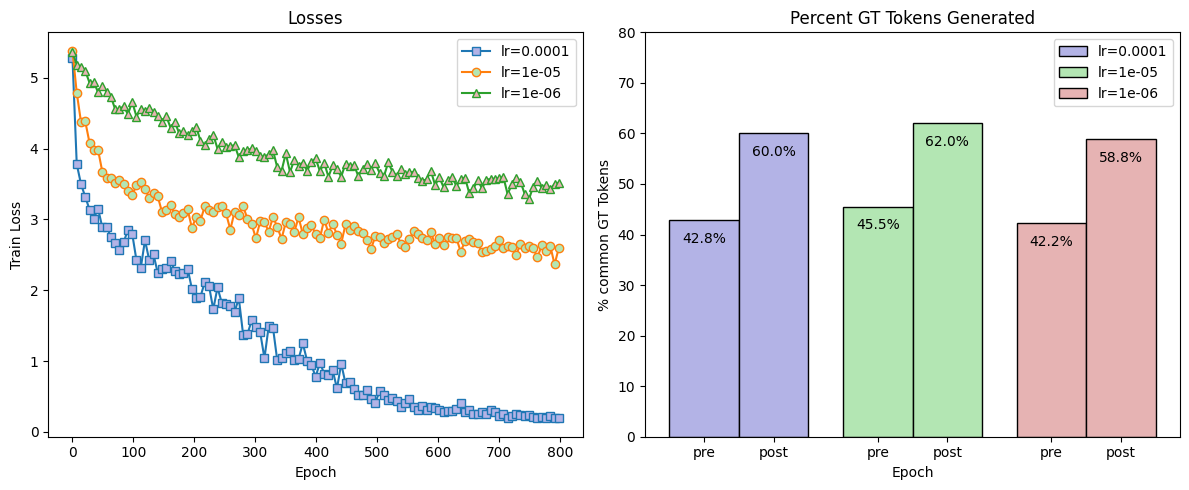

In [136]:
# Visualize the Results
_, axs = plt.subplots(1,2,figsize=(12,5))

colors = [[.7,.7,.9],[.7,.9,.7],[.9,.7,.7]]
shapes = 'so^'

# store bars so we can annotate them
pre_bars  = []
post_bars = []

for i in range(3):

    axs[0].plot(range(0,num_epochs,7),
                lr_evals[i]['train_loss'][::7],
                markerfacecolor=colors[i],
                marker=shapes[i],
                label=f"lr={lr_evals[i]['learning_rate']}")


    b1 = axs[1].bar([i-0.2], lr_evals[i]['pre_train_eval'],
                    width=0.4, color=colors[i], edgecolor='k',
                    label=f"lr={lr_evals[i]['learning_rate']}")

    b2 = axs[1].bar([i+0.2], lr_evals[i]['post_train_eval'],
                    width=0.4, color=colors[i], edgecolor='k')

    pre_bars.append(b1)
    post_bars.append(b2)

for bars in pre_bars + post_bars:
    for bar in bars:
        height = bar.get_height()
        axs[1].text(
            bar.get_x() + bar.get_width()/2,
            height - 5,                     # small vertical offset
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

axs[0].set(xlabel="Epoch",ylabel="Train Loss", title="Losses")
axs[0].legend()

axs[1].set(xlabel="Epoch",xticks=[-.2,.2,.8,1.2,1.8,2.2],xticklabels=['pre','post','pre','post','pre','post'],ylabel='% common GT Tokens',title='Percent GT Tokens Generated',ylim=[0,80])
# axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axs[1].legend()

plt.tight_layout()
plt.show()
